In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
import seaborn as sns

In [11]:
def radius_95(Count):
    if 0<np.log10(Count)<=2.1393:
        return 10**(-0.4958*np.log10(Count)+0.1932)
    elif 2.1393<np.log10(Count)<=3.3:
        return 10**(-0.2064*np.log10(Count)-0.4260)

In [23]:
path_xray = "C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/NGC 6218/xrays.json"
BS_RA = 0
BS_Decl = 0
distance_parsecs = 5000

In [35]:
with open(path_xray, "r") as f:
    NGC6809_sources = json.load(f)

df = pd.DataFrame(NGC6809_sources).transpose()

#I'm going to take the total value as it starts from 0.5 instead of 0.3.
df.rename(columns = {"f_0.3-7" : "f_0.5-7"}, inplace = True)

ra_parts = df["RA"].str.extract(r"(\d+):(\d+):([\d\.]+)")
df["RA"] = 15*(ra_parts[0].astype(float)+ra_parts[1].astype(float)/60+ra_parts[2].astype(float)/3600) + BS_RA

decl_parts = df["DEC"].str.extract(r"([+-]?\d+):(\d+):([\d\.]+)")
df["Decl"] = decl_parts[0].astype(float)-decl_parts[1].astype(float)/60-decl_parts[2].astype(float)/3600 + BS_Decl

df["total_count"] = df["Soft"]+df["Medium"]+df["Hard"]

df['r95'] = np.nan

for i in df.index:
    df.loc[i, "r95"] = radius_95(df["total_count"][i])/3600
d = distance_parsecs * 3.26156 *30000000000*365*24*60*60

df["Lx_0.5-7.0"] = df["f_0.5-7"].astype(float) * 4 * np.pi * d*d
df["Lx_0.5-2.5"] = df["f_0.5-2.5"].astype(float) * 4 * np.pi * d*d
df["Lx_2.5-7.0"] = df["Lx_0.5-7.0"] - df["Lx_0.5-2.5"]

df.drop(columns = ["DEC", "Soft", "Medium", "Hard", "f_0.5-7", "f_0.5-2.5", "Counterpart", "total_count"], inplace = True)
df.index.name = "id"

df["Lx_0.5-7.0"] = df["Lx_0.5-2.5"] + df["Lx_2.5-7.0"]
df["Lx_0.5-2.5 / Lx_2.5-7.0"] = df["Lx_0.5-2.5"]/df["Lx_2.5-7.0"]
df["log(Lx_0.5-7.0)"] = np.log10(df["Lx_0.5-7.0"])
df["log(Lx_0.5-2.5 / Lx_2.5-7.0)"] = np.log10(df["Lx_0.5-2.5 / Lx_2.5-7.0"])
df["log(Lx_0.5-2.5)"] = np.log10(df["Lx_0.5-2.5"])

conditions = [(df["log(Lx_0.5-7.0)"] >= 31.6020599913) & (-3.996566*df["log(Lx_0.5-2.5 / Lx_2.5-7.0)"] + 33.6003433 - df["log(Lx_0.5-7.0)"] < 0),
          (df["log(Lx_0.5-7.0)"] >= 31.6020599913) & (-3.996566*df["log(Lx_0.5-2.5 / Lx_2.5-7.0)"] + 33.6003433 - df["log(Lx_0.5-7.0)"] >= 0),
          (df["log(Lx_0.5-7.0)"] < 31.6020599913) & (df["log(Lx_0.5-7.0)"] >= 30.6020599913),
          df["log(Lx_0.5-7.0)"] < 30.6020599913]
choices = ["LMXRB",'CV','CV & AB','AB']

df ["Hardness_classification"] = np.select(conditions, choices, default="")
df.drop(columns = ["Lx_0.5-7.0", "Lx_0.5-2.5 / Lx_2.5-7.0", "Lx_0.5-2.5", "Lx_2.5-7.0"], inplace = True)
df

C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,RA,Decl,r95,log(Lx_0.5-7.0),log(Lx_0.5-2.5 / Lx_2.5-7.0),log(Lx_0.5-2.5),Hardness_classification
id,,,,,,,
CX1,251.815363,-1.946361,0.000033,32.342734,-0.014163,32.034565,CV
CX2,251.826650,-1.948228,0.000119,31.060188,-0.013573,30.752318,CV & AB
CX3,251.824067,-1.956300,0.000157,30.822209,-0.167955,30.429133,CV & AB
CX4,251.832942,-1.954533,0.000169,30.754610,0.038426,30.472368,CV & AB
CX5,251.814725,-1.940525,0.000195,30.631192,-0.244351,30.191024,CV & AB
CX6,251.821017,-1.979311,0.000193,30.695964,0.071321,30.429133,CV & AB
CX7,251.891433,-1.886606,0.000034,32.286761,-0.071312,31.948613,CV
CX8,251.769771,-1.954236,0.000050,31.820249,-0.135504,31.446203,CV
CX9,251.839100,-1.922614,0.000062,31.631192,0.048643,31.353803,CV


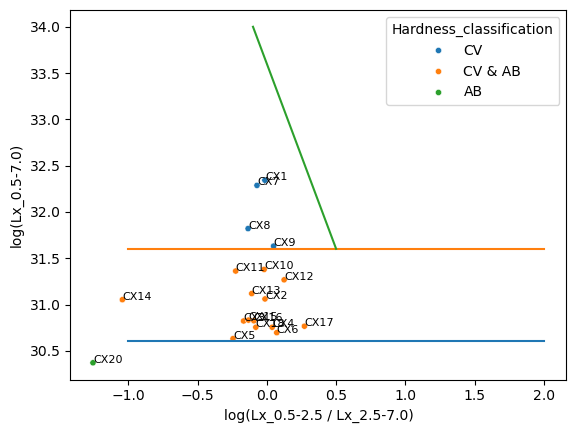

In [39]:
x_axis = np.linspace(-1, 2, 2)
point_1 = [-0.1, 0.5]
point_2 = [34, 31.6020599913]
sns.scatterplot(data=df, x="log(Lx_0.5-2.5 / Lx_2.5-7.0)", y="log(Lx_0.5-7.0)", hue="Hardness_classification", s = 20)
for i in range(len(df["log(Lx_0.5-7.0)"])):
    plt.annotate(df.index[i], (df["log(Lx_0.5-2.5 / Lx_2.5-7.0)"].iloc[i], df["log(Lx_0.5-7.0)"].iloc[i]), fontsize = 8)
plt.plot(x_axis, [30.6020599913, 30.6020599913])
plt.plot(x_axis, [31.6020599913, 31.6020599913])
plt.plot(point_1, point_2)
plt.show()